<a href="https://colab.research.google.com/github/joseflix/DocenciaUAB/blob/master/MN1/2025-2026/Practiques/Exercici_Recu_(solucions).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pràctica Recuperació: Plaques solars i bateries (solucions)**

##**Exercici**

Una petita illa es proveeix d'energia exclusivament mitjançant plaques solars i un sistema de bateries.

*   **Generació diària**: Cada dia, l'energia solar generada segueix una distribució Normal amb mitjana $\mu = 150$ MWh i desviació estàndard $\sigma = 30$ MWh (si un dia dóna negatiu, es considera 0).
*   **Consum diari**: El consum de l'illa no és fix, sinó que depèn del dia. Segueix una distribució Uniforme entre $100$ i $180$ MWh.
*   **Emmagatzematge**: L'illa comença el Dia 1 amb les bateries plenes (Capacitat màxima = $C$ MWh). Cada dia, el balanç d'energia (Generació - Consum) s'afegeix o es resta a la bateria. La bateria no pot superar la capacitat $C$ (l'excés es perd) ni pot baixar de 0.
*   **Apagada (Blackout)**: Si un dia el nivell de la bateria arriba a 0 i encara hi ha demanda, es produeix un "blackout".

## <font color=green>**Entrega 1**</font>

Escriu una funció *simula_any(C)* que rebi com a paràmetre la capacitat màxima de la bateria $C$ i simuli el funcionament de l'illa durant 365 dies. La funció ha de retornar quantes vegades hi ha hagut un blackout durant l'any i el nivell de la capacitat de la bateria per a cada dia de l'any. **[3 punts]**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# TASCA 1: Funció per simular un any
def simula_any(C):
    nivell_bateria = C  # Comencem amb la bateria plena
    blackouts = 0       # Comptador de dies amb apagada

    # Generem dades aleatòries per als 365 dies
    # Generació solar: Distribució Normal (mitjana 150, desv. 30)
    generacio = np.random.normal(150, 30, 365)
    # Assegurem que cap dia tingui generació negativa (trunquem a 0)
    generacio[generacio < 0] = 0

    # Consum: Distribució Uniforme entre 100 i 180
    consum = np.random.uniform(100, 180, 365)

    historial_bateria = [] # Per guardar l'evolució i fer la gràfica

    for g, c in zip(generacio, consum):
        # Balanç net d'energia del dia
        balanc = g - c
        nivell_bateria += balanc

        # Comprovem els límits de la bateria
        if nivell_bateria < 0:
            blackouts += 1
            nivell_bateria = 0  # No pot baixar de 0
        elif nivell_bateria > C:
            nivell_bateria = C  # L'excés d'energia es perd

        historial_bateria.append(nivell_bateria)

    return blackouts, historial_bateria

## <font color=green>**Entrega 2**</font>

Comprova la teva funció fent una gràfica de l'evolució del nivell de la bateria (de 0 a 365 dies) assumint una capacitat $C = 50$ MWh. També imprimeix per pantalla la quantita de 'blackout days' que hi ha hagut en un any. **[2 punts]**

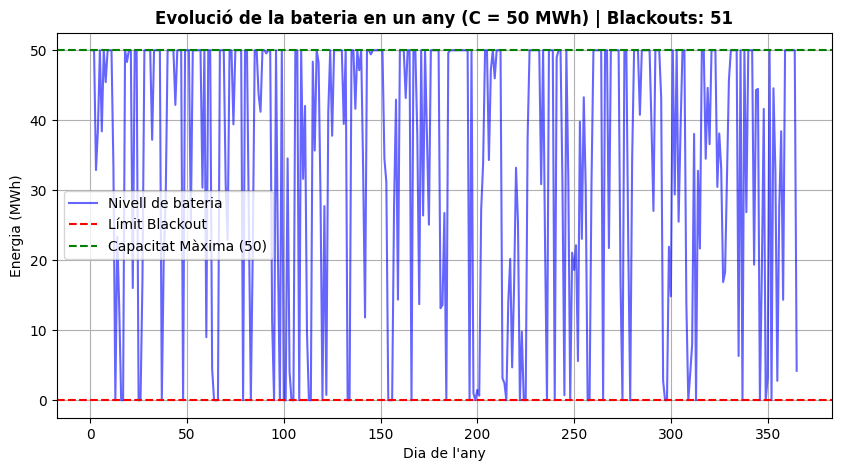

Dies amb blackout elèctric: 51


In [ ]:
# TASCA 2: Execució i gràfica per a C = 50 MWh
C_test = 50
blackouts_50, historial_50 = simula_any(C_test)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 366), historial_50, label="Nivell de bateria", color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', label="Límit Blackout")
plt.axhline(C_test, color='green', linestyle='--', label="Capacitat Màxima (50)")

plt.title(f"Evolució de la bateria en un any (C = {C_test} MWh) | Blackouts: {blackouts_50}", fontweight='bold')
plt.xlabel("Dia de l'any")
plt.ylabel("Energia (MWh)")
plt.legend(loc='best')
plt.grid(True)
plt.show()

print("Dies amb blackout elèctric:", blackouts_50)

## <font color=green>**Entrega 3**</font>

Com que el clima i el consum són aleatoris, una sola simulació d'un any no és suficient. Crea una funció probabilitat_blackout(C) que executi la simulació d'un any N=1.000 vegades (Mètode de Monte Carlo) i retorni el promig de blackouts per any i el seu error (com a $\sqrt{\sigma}/N$), i la probabilitat que hi hagi almenys un blackout en un any.

Per a una bateria de 50MWh, imprimeix per pantalla la probabilitat de patir blackouts en un any, i el nombre de blackouts per any amb el seu error, fruit d'aquesta simulació. **[3 punts]**

In [ ]:
def blackout_mc(C, N_simulacions=1000):
    anys_amb_blackout = 0
    b = []
    for _ in range(N_simulacions):
        blackouts, _ = simula_any(C)
        b.append(blackouts)
        if blackouts > 0:
            anys_amb_blackout += 1

    probabilitat = anys_amb_blackout / N_simulacions
    return np.mean(b), np.std(b)/np.sqrt(N_simulacions), probabilitat

# Fem una prova ràpida per a C = 50
bl, bl_e, p = blackout_mc(50)
print(f"Amb una bateria de 50 MWh, la probabilitat de patir blackouts en un any és del {p*100:.1f}%")
print(f"Amb una bateria de 50 MWh, el nombre de blackouts per any és de {bl:.1f} +/- {bl_e:0.1f}")

Amb una bateria de 50 MWh, la probabilitat de patir blackouts en un any és del 100.0%
Amb una bateria de 50 MWh, el nombre de blackouts per any és de 59.6 +/- 0.3


## <font color=green>**Entrega 4**</font>

L'ajuntament de l'illa vol comprar bateries noves. El seu objectiu és que la probabilitat de patir algun blackout durant l'any sigui inferior al 5%. Utilitzant el mètode numèric desenvolupat, troba quina és la capacitat mínima $C$ (començant a 10 MWh, i augmentant en intervals de 10 MWh) que han d'instal·lar per complir aquest objectiu. Fes també una gràfica de la probabilitat vs. la capacitat mínima $C$. **[2 punts]**

Iniciant cerca de la capacitat òptima (Objectiu: Probabilitat < 5%)...\n
Capacitat avaluada: 10 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 20 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 30 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 40 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 50 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 60 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 70 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 80 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 90 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 100 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 110 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 120 MWh --> Probabilitat de blackout: 100.0%
Capacitat avaluada: 130 MWh --> Probabilitat de blackout: 99.9%
Capacitat avaluada: 140 MWh --> Probabilitat de blackout: 99.7%
Capacitat avaluada: 150 MWh 

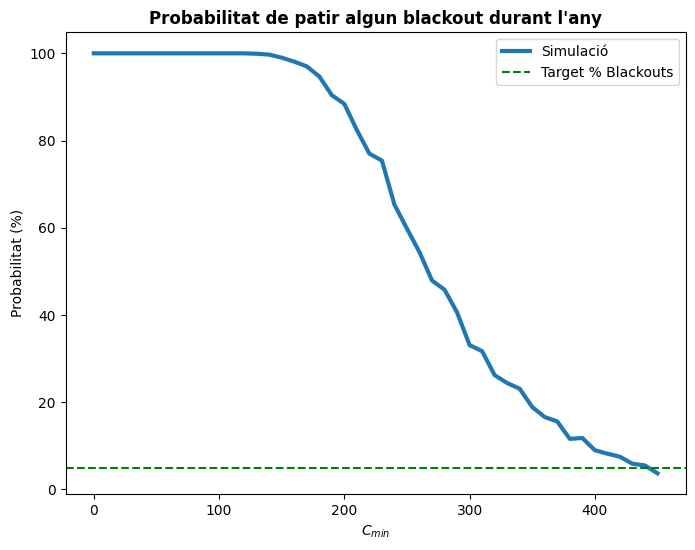

In [ ]:
# TASCA 4: Cerca de la capacitat òptima
capacitat = 0
probabilitat = 1.0  # Inicialitzem al 100% per començar el bucle

c_min = []
p_b = []

p_b.append(probabilitat*100)
c_min.append(capacitat)

print("Iniciant cerca de la capacitat òptima (Objectiu: Probabilitat < 5%)...\\n")

# Bucle per buscar la capacitat augmentant de 10 en 10
while probabilitat >= 0.05:
    capacitat += 10
    b, be, probabilitat = blackout_mc(capacitat, N_simulacions=1000)
    p_b.append(probabilitat*100)
    c_min.append(capacitat)
    print(f"Capacitat avaluada: {capacitat} MWh --> Probabilitat de blackout: {probabilitat*100:.1f}%")

print(f"\\nRESUM:")
print(f"La capacitat mínima que cal instal·lar és de {capacitat} MWh,")
print(f"aconseguint un risc de blackout del {probabilitat*100:.1f}%.")

plt.figure(figsize=(8, 6))
plt.plot(c_min, p_b, '-', linewidth=3, label='Simulació')
plt.axhline(5, color='green', linestyle='--', label="Target % Blackouts")
plt.title("Probabilitat de patir algun blackout durant l'any", fontweight='bold')
plt.xlabel(r"$C_{min}$")
plt.ylabel("Probabilitat (%)")
plt.legend()
plt.show()